In [1]:
!pip install pandasql

**IMPORTS**

In [2]:
import pandas as pd
import pandasql as psql
from pandasql import sqldf
import numpy as np
import calendar

import seaborn as sns
import matplotlib.pyplot as plt
#from wordcloud import WordCloud

import warnings
warnings.filterwarnings( 'ignore' )

sns.set(style='darkgrid')
plt.rcParams["figure.figsize"] = (15,7)

**LOADING DATA**

In [3]:
reviews = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")
products  = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")
customers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
orders = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")
orders_items = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")

In [4]:
df_reviews =  psql.sqldf("select * from reviews")
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [5]:
df_customers =  psql.sqldf("select * from customers")
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
df_products =  psql.sqldf("select * from products")
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
df_orders =  psql.sqldf("select * from orders")
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
query = '''SELECT REVISAO.REVIEW_ID,
                  REVISAO.REVIEW_SCORE,
                  REVISAO.REVIEW_COMMENT_TITLE,
                  REVISAO.REVIEW_COMMENT_MESSAGE,
                  REVISAO.REVIEW_CREATION_DATE,
                  PEDIDOS.ORDER_STATUS,
                  PEDIDOS.ORDER_APPROVED_AT,
                  PEDIDOS.ORDER_DELIVERED_CARRIER_DATE,
                  PEDIDOS.ORDER_ESTIMATED_DELIVERY_DATE,
                  CLIENTES.CUSTOMER_STATE,
                  PRODUTOS.PRODUCT_CATEGORY_NAME
           FROM reviews REVISAO
                INNER JOIN orders PEDIDOS
                ON REVISAO.ORDER_ID = PEDIDOS.ORDER_ID
                INNER JOIN customers CLIENTES
                ON CLIENTES.CUSTOMER_ID = PEDIDOS.CUSTOMER_ID
                INNER JOIN orders_items ITENS 
                ON PEDIDOS.ORDER_ID = ITENS.ORDER_ID
                INNER JOIN products PRODUTOS 
                ON PRODUTOS.PRODUCT_ID = ITENS.PRODUCT_ID'''

In [9]:
df = psql.sqldf(query)

**DATA DESCRIPTION**

In [10]:
df.shape

(112372, 11)

In [11]:
df.isna().sum()

review_id                            0
review_score                         0
review_comment_title             98938
review_comment_message           64730
review_creation_date                 0
order_status                         0
order_approved_at                   15
order_delivered_carrier_date      1184
order_estimated_delivery_date        0
customer_state                       0
product_category_name             1598
dtype: int64

In [12]:
df.dtypes

review_id                        object
review_score                      int64
review_comment_title             object
review_comment_message           object
review_creation_date             object
order_status                     object
order_approved_at                object
order_delivered_carrier_date     object
order_estimated_delivery_date    object
customer_state                   object
product_category_name            object
dtype: object

In [13]:
df.columns

Index(['review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date', 'order_status',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_estimated_delivery_date', 'customer_state',
       'product_category_name'],
      dtype='object')

**PREPROCESSING**

In [14]:
df1 = df.copy()

In [15]:
df1.head()

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,order_status,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,customer_state,product_category_name
0,7bc2406110b926393aa56f80a40eba40,4,None,None,2018-01-18 00:00:00,delivered,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-02-02 00:00:00,SP,esporte_lazer
1,7bc2406110b926393aa56f80a40eba40,4,None,None,2018-01-18 00:00:00,delivered,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-02-02 00:00:00,SP,esporte_lazer
2,80e641a11e56f04c1ad469d5645fdfde,5,None,None,2018-03-10 00:00:00,delivered,2018-02-28 12:48:39,2018-03-02 19:08:15,2018-03-14 00:00:00,SP,informatica_acessorios
3,228ce5500dc1d8e020d8d1322874b6f0,5,None,None,2018-02-17 00:00:00,delivered,2018-02-03 10:33:41,2018-02-06 16:18:28,2018-03-09 00:00:00,BA,informatica_acessorios
4,e64fb393e7b32834bb789ff8bb30750e,5,None,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,delivered,2017-04-09 17:55:19,2017-04-10 14:24:47,2017-05-10 00:00:00,SC,ferramentas_jardim


In [16]:
%%time

df1 = df1.drop_duplicates()

# rename columns
cols = ['review_id', 'score', 'review_title', 'review_message', 'review_date',
        'order_status', 'order_approved','delivered_carrier','estimated_delivery',
        'customer_state', 'product_category']
df1.columns = map(str.lower, cols)

#Change types 
df1['score'] = df1['score'].astype(int)

# Parse Dates to datetime pandas
for col in df1[['review_date', 'order_approved','delivered_carrier','estimated_delivery']]:
    df1[col] = pd.to_datetime(df1[col])

# check if there is a empty values. If true, fill With NaN
for col in df1:
    df1[col] = df1[col].apply(lambda x: np.nan if x == '' else x )
    
#ordering columns
df1 = df1[['review_id','review_date', 'order_approved','delivered_carrier','estimated_delivery', 
            'product_category','order_status','review_title', 'review_message','customer_state','score']]

CPU times: user 4.05 s, sys: 22.1 ms, total: 4.07 s
Wall time: 4.08 s


In [17]:
df1.isna().sum()

review_id                 0
review_date               0
order_approved           14
delivered_carrier      1000
estimated_delivery        0
product_category       1448
order_status              0
review_title          87625
review_message        58317
customer_state            0
score                     0
dtype: int64

In [18]:
df1.sample(3)

,review_id,review_date,order_approved,delivered_carrier,estimated_delivery,product_category,order_status,review_title,review_message,customer_state,score
78805,99903107a252f43f975ea0915271716c,2017-12-21,2017-12-09 12:31:31,2017-12-11 18:10:17,2018-01-04,None,delivered,None,None,SP,4
72525,00a3825bb383203a9bd5911d3195e826,2017-08-19,2017-08-08 20:25:18,2017-08-12 10:48:51,2017-09-08,utilidades_domesticas,delivered,None,None,GO,5
2305,7e1c9aed5a984e713d373ec31c756f44,2018-06-23,2018-06-15 20:03:23,2018-06-18 14:41:00,2018-07-25,beleza_saude,delivered,None,None,RJ,5


**EXLORATORY DATA ANALYSIS**

**SCORES**

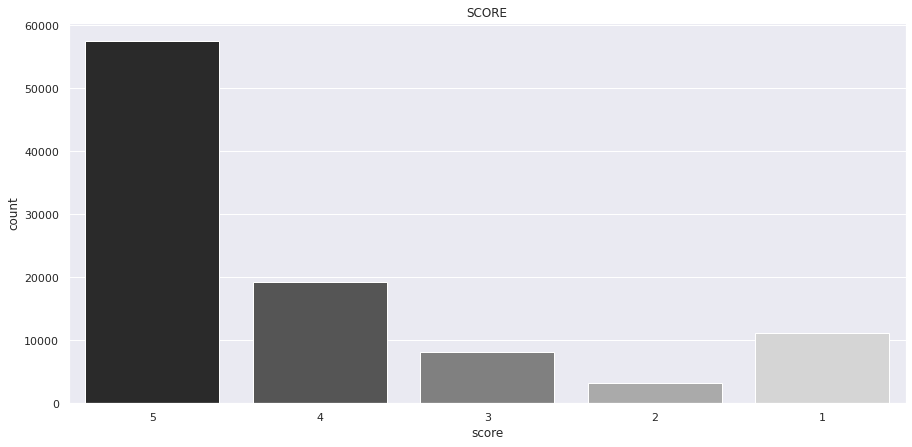

In [19]:
sns.countplot(x='score', data=df1, palette='gist_yarg_r', order=[5,4,3,2,1])
plt.title("SCORE", size=12);

**Which product categories have the most sales?**

In [20]:
mais_vendidos = df1.groupby(['product_category'], as_index=False)['customer_state'].count().rename( columns = {'customer_state':'total'})
# calculo porcentagem
mais_vendidos['%'] = round((mais_vendidos['total'] / mais_vendidos['total'].sum()) * 100, 2)
mais_vendidos.nlargest(3, 'total')

,product_category,total,%
13,cama_mesa_banho,9432,9.64
11,beleza_saude,8826,9.02
32,esporte_lazer,7720,7.89


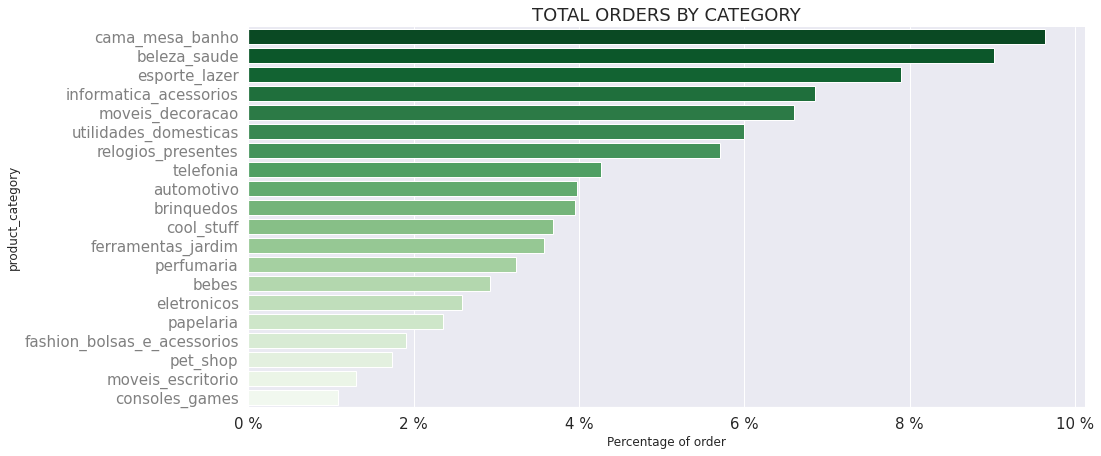

In [21]:
g = sns.barplot(y='product_category', x='%', palette='Greens_r', data=mais_vendidos.nlargest(20, '%'))

plt.title('TOTAL ORDERS BY CATEGORY', size=18)
plt.yticks(fontsize=15, color='gray');
plt.xticks([0,2,4,6,8,10],['0 %', '2 %', '4 %', '6 %', '8 %', '10 %'], fontsize=15);
plt.xlabel("Percentage of order");
g.spines['top'].set_visible(False)
g.spines['right'].set_visible(False)

The analysis of the chart shows the percentage distribution of product categories in relation to total orders. It is evident that the company's product portfolio is well diversified. The category "cama_mesa_banho" holds the largest share, but even so, it represents less than 10% of the total orders. This indicates that the company is not overly reliant on any single category for its revenue.

As a result, any negative impact on sales within a specific category is unlikely to cause a significant drop in the company’s overall revenue. Other categories such as "beleza_saúde," "esporte_lazer," and "informática_acessórios" also contribute significantly, further supporting the idea of diversified risk. This diversification provides greater financial and operational security for the company by reducing its dependence on one category.

Additionally, the company can benefit from this flexibility by adjusting its marketing and inventory strategies. Prioritizing high-growth categories while maintaining strong campaigns in stable categories, such as "cama_mesa_banho" and "beleza_saúde," would enable the company to enhance its overall performance and mitigate potential risks in the market.

**SCORE BY PRODUCT CATEGORY**

In [22]:
def count_product_category(score, data, x, y, n = 20):
    #filtering the dataframe by score, to generate the graph for each one
    data = data[ data['score'] == score ]
    count = data.groupby(col, as_index=False)['customer_state'].count().rename( columns = {'customer_state':'total'})
    count['%'] = round((count['total'] / count['total'].sum()) * 100, 2)
    
    g = sns.barplot(x=x, y =y, data = count.nlargest(n, 'total'), palette='icefire_r')
    
    # config plot area
    plt.title(f'score {score} by {col}', size=13,  fontweight="bold")
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    plt.subplots_adjust(left=0.1, 
                    bottom=0.3,  
                    right=0.9,  
                    top=2.3,  
                    wspace=0.4,  
                   hspace=1)
    return g

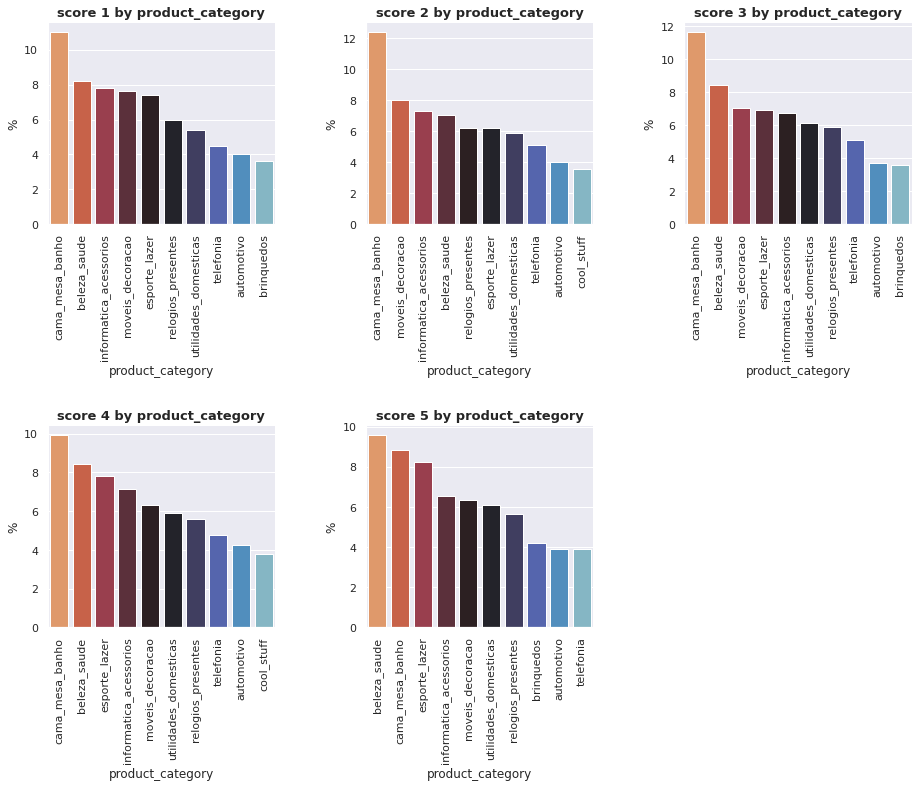

In [23]:
for i in range(1,6):
    plt.subplot( 3, 3, i );
    count_product_category(i, df1, 'product_category', '%', 10);
    plt.xticks(rotation=90);

The cama_mesa_banho category consistently appears in first place across all score ranges. This is likely due to the high number of orders in this category. Generally, the larger the number of requests for a category, the higher the likelihood it will rank across all score levels.

However, a noteworthy positive point is that the beleza_saúde category takes first place specifically in the score 5 range, indicating particularly strong performance in customer satisfaction or preference in this segment.

**Which States are there more Order?**

In [24]:
df1.sample()

,review_id,review_date,order_approved,delivered_carrier,estimated_delivery,product_category,order_status,review_title,review_message,customer_state,score
68506,1e3c49f4225d7bfbcaed0e6eb4cccc2f,2018-03-07,2018-02-22 12:20:23,2018-02-22 23:09:19,2018-03-26,beleza_saude,delivered,None,None,RS,5


In [25]:
def count_order_by_state(col, data, y, n = 20):
    count = data.groupby(col, as_index=False)['order_status'].count().rename( columns = {'order_status':'total'})
    count['%'] = round((count['total'] / count['total'].sum()) * 100, 2)
    
    g = sns.barplot(x=col, y =y, data = count.nlargest(n, 'total'), palette='Greys_r')
    
    col = col.replace("_", " ")
    plt.title(f' Total order by {col}', size=18,  fontweight="bold")
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    return g

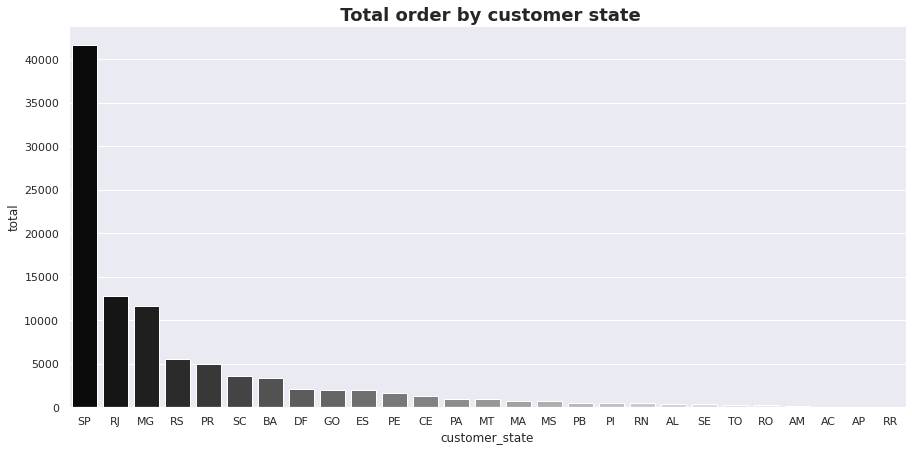

In [26]:
count_order_by_state('customer_state', df1, 'total', 27);

**Does the delivery time affect the score?**

In [27]:
df_delivery = df1.copy()

In [28]:
df_delivery = df_delivery.dropna()

Analyzing the data, it is clear that deliveries are made almost unanimously within the same month. Therefore, I will analyze the differences between the days.


In [29]:
import pandas as pd
import numpy as np

def days_to_delivery(data):
    # Convert the order approval and delivery dates to pandas datetime
    order_approved = pd.to_datetime(data['order_approved'], errors='coerce')
    delivered_carrier = pd.to_datetime(data['delivered_carrier'], errors='coerce')
    
    # Return NaN if either date is missing or invalid
    if pd.isna(order_approved) or pd.isna(delivered_carrier):
        return np.nan
    
    # Return NaN if the delivery date is earlier than the order approval date
    if delivered_carrier < order_approved:
        return np.nan
    
    # Calculate and return the number of days between the two dates
    return (delivered_carrier - order_approved).days

# Apply the function to the DataFrame
df_delivery['days_to_delivery'] = df_delivery.apply(days_to_delivery, axis=1)


In [30]:
df_delivery[df_delivery['days_to_delivery'] != np.nan ].sample(6)

,review_id,review_date,order_approved,delivered_carrier,estimated_delivery,product_category,order_status,review_title,review_message,customer_state,score,days_to_delivery
89666,6a4c6a135b1514c92b83ce618062b323,2018-06-21,2018-06-13 02:18:55,2018-06-13 11:46:00,2018-07-12,utilidades_domesticas,delivered,Ótima,"Produto correto, bem embalado, em perfeito est...",RS,5,0.0
15023,2857dda12e9a41caf56c5ce5fb4a7e76,2018-05-30,2018-05-26 21:55:10,2018-05-28 15:36:00,2018-06-20,eletrodomesticos_2,delivered,Nota 10,"Encomenda entregue bem antes do prazo, recomen...",RS,5,1.0
105798,cd6f4076911f8f6812d671bc41a0df9e,2018-06-23,2018-06-08 11:54:43,2018-06-15 13:57:00,2018-07-04,papelaria,delivered,Adequado,Levou 15 dias pra chegar .. chegou tudo certo ...,SP,4,7.0
57630,7e7a35821013735db8dbc91358d5a228,2018-05-18,2018-04-18 16:55:37,2018-04-20 22:26:19,2018-05-16,utilidades_domesticas,delivered,Péssima compra,O produto ainda não foi entregue e já passou d...,RN,1,2.0
70014,32a9c629c7bc3cd078b2162d55e2cd33,2018-08-31,2018-08-28 17:55:18,2018-08-29 13:17:00,2018-09-03,informatica_acessorios,delivered,Rápido e simples,Produto entregue antes do prazo.,SP,4,0.0
74495,5ab27d594fae9a3120116613cec029bd,2018-05-03,2018-04-24 17:46:25,2018-04-23 12:34:51,2018-05-21,cine_foto,delivered,SUPER RECOMENDO,"MUITO BOM O PRODUTO, RECOMENDO.",RJ,5,NaN


In [31]:
# ANALYZING THE BASE, IT IS PERCEIVED THAT THERE ARE DIVERGENCES BETWEEN THE DATES. THEREFORE,
#ALL DIVERGENT DATA HAS BEEN FILLED WITH NAN SO THEY CAN BE PROCESSED FURTHER.

def highlight_cols(s):
    color = 'orange'
    return 'background-color: %s' % color

df_delivery[df_delivery['days_to_delivery'].isna()].head(2)\
.style.applymap(highlight_cols, subset=pd.IndexSlice[:, ['order_approved', 'delivered_carrier']])

,review_id,review_date,order_approved,delivered_carrier,estimated_delivery,product_category,order_status,review_title,review_message,customer_state,score,days_to_delivery
33,d21bbc789670eab777d27372ab9094cc,2018-07-10 00:00:00,2018-07-05 16:33:00,2018-07-05 15:55:00,2018-07-23 00:00:00,beleza_saude,delivered,Ótimo,Loja nota 10,RJ,5,nan
257,4656b8ed41c17f6be05e911e211ecd8f,2018-05-08 00:00:00,2018-04-24 19:17:35,2018-04-23 22:33:05,2018-06-01 00:00:00,beleza_saude,delivered,recomendo,Comecei a usar agora,RJ,3,nan


The base has some values with negative delivery time, which can indicate 3 things:

1. There is something wrong in the calculation I made and I need to check it;

2. The dates are wrong in the database, causing this distortion in the delivery time;

3. The carrier did an incredible job and went back in time to deliver - I think it's unlikely.

**Fill NAN with average delivery days by state. Delivery time varies by state, because Brazil is very big**

In [32]:
# saving the index of the nan lines, to be able to filter and check if the average values ​​were correctly imputed.
list_index = list(df_delivery[df_delivery['days_to_delivery'].isna() ].index)

In [33]:
# Filling NaN with time - in days - delivery average according to the state.

df_delivery['days_to_delivery'] = df_delivery.groupby(['customer_state'])['days_to_delivery']\
.transform(lambda x: x.fillna( abs(x.mean()) ))

In [34]:
df_delivery[df_delivery.index.isin(list_index)].head(2)

,review_id,review_date,order_approved,delivered_carrier,estimated_delivery,product_category,order_status,review_title,review_message,customer_state,score,days_to_delivery
33,d21bbc789670eab777d27372ab9094cc,2018-07-10,2018-07-05 16:33:00,2018-07-05 15:55:00,2018-07-23,beleza_saude,delivered,Ótimo,Loja nota 10,RJ,5,2.189076
257,4656b8ed41c17f6be05e911e211ecd8f,2018-05-08,2018-04-24 19:17:35,2018-04-23 22:33:05,2018-06-01,beleza_saude,delivered,recomendo,Comecei a usar agora,RJ,3,2.189076


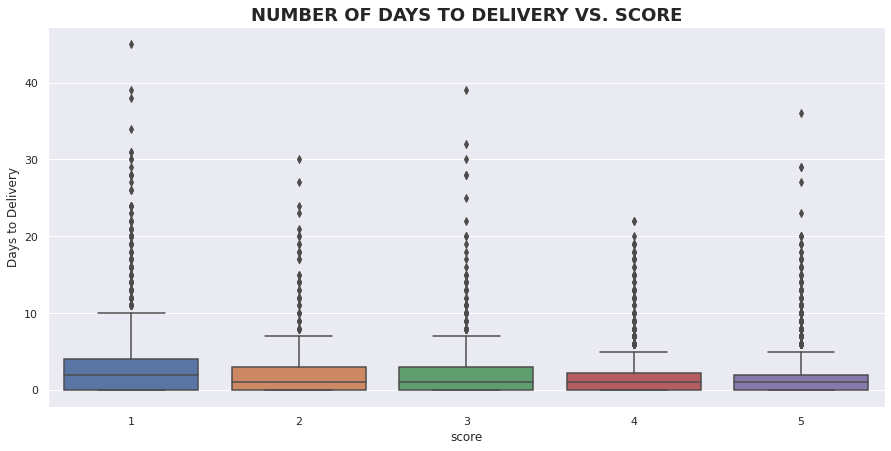

In [35]:
sns.boxplot(y='days_to_delivery', x='score', data=df_delivery);
plt.title('NUMBER OF DAYS TO DELIVERY VS. SCORE', size = 18, fontweight="bold");
plt.ylabel("Days to Delivery");

*Observations*

**Distribution of Delivery Days:**

***Score 1 and 2:*** 

Both have a similar interquartile range, but score 1 shows more outliers, indicating greater variation in delivery days.

***Scores 3, 4, and 5:*** 

These scores have fewer outliers compared to scores 1 and 2, suggesting a more consistent distribution of delivery days.
Median and Interquartile Range:

The line inside each box represents the median number of delivery days.

The length of the box shows the interquartile range (IQR), which is the difference between the first quartile (Q1) and the third quartile (Q3).
Outliers:

Individual points outside the “whiskers” of the box plot indicate outliers in delivery days.


*Interpretation*

**Score 1:** Shows the highest variation in delivery days, possibly indicating issues with consistency or frequent delays.

**Scores 3 to 5:** Show less variation and fewer outliers, suggesting more consistent deliveries and potentially higher customer satisfaction.

**Analyzing the score with high delivery time**

In [36]:
df_outlier_devlivery = df_delivery[df_delivery['days_to_delivery'] > 10 ]

<AxesSubplot:xlabel='score', ylabel='count'>

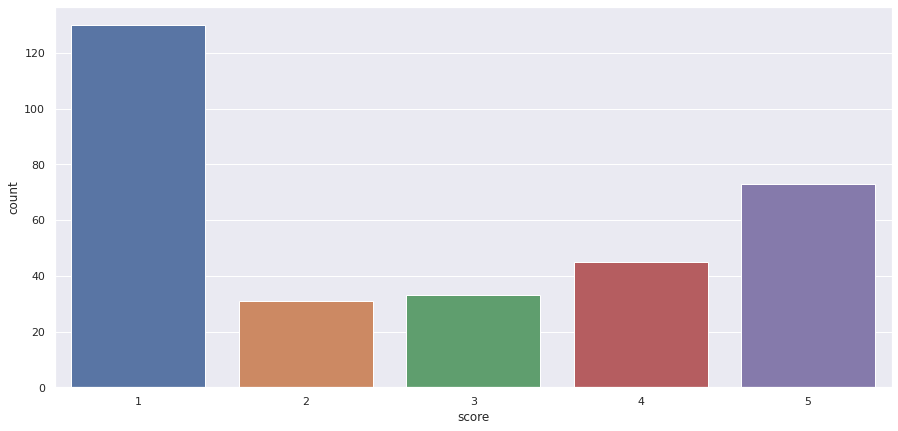

In [37]:
sns.countplot(x='score', data=df_outlier_devlivery)